# Tutorial 3: Generating artificial sounds with known rate and scale

This tutorial explains how to build synthetic signals with a known rate and/or scale using the functions in  `neural_audio.utils.mathfuncs`:
- `gen_temporal_modulations_rate`
- `gen_temporal_bursts_rate`
- `gen_spectral_modulations_scale`
- `gen_ripple`

Each returns a 1-D waveform that can be passed straight to `wav2aud`. Because the rate and scale are fixed in advance, these signals are useful for building intuition and for testing: the cortical representation from `aud2cor` should place energy in exactly the rate and scale channels that were requested. To help understand the physical meaning of changing the rate and scale parameters, the generated sounds can be played by clicking the 'play' button on the audio widget. 

For your convenience, all `aud2cor` calls are placed in a separate cell to those that generate the corresponding synthetic sound so parameters may be adjusted without a computationally expensive call each time the sound parameters are changed.

## Interpreting rate and scale

An audiogram lays out sound energy over two axes: time (horizontal) and frequency (vertical, log-spaced). Rate and scale describe how that energy is patterned along each axis.

- **Rate** (temporal modulation, measured in Hz) describes how quickly the energy at a given frequency rises and falls over time.

- **Scale** (spectral modulation, measured in cycles per octave, where one octave is a doubling of frequency) describes how finely the energy is patterned across frequency at a single instant. A coarse (low) scale means the energy varies smoothly and broadly across frequency; a fine (high) scale means it alternates between peaks and troughs many times within one octave, as happens for a sound with closely spaced harmonics.

`aud2cor` measures both properties at once, reporting how much each combination of rate and scale contributes to a sound. The functions below produce signals that isolate one or both of these properties. 

### Setup

The imports and the rate and scale vectors used throughout are defined once below. **As in Tutorial 2, a reduced resolution of 16 rates x 16 scales is used to keep the `aud2cor` computations lighter.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig


from neural_audio.wav2aud import wav2aud
from neural_audio.aud2cor import aud2cor
from neural_audio.utils.visualize_outputs import plot_spectrogram, plot_cr_projection, plot_cr_temporal
from neural_audio.utils.mathfuncs import gen_spectral_modulations_scale, gen_ripple
from IPython.display import Audio, display

import neural_audio.utils.mathfuncs as mf

# Reduced-resolution rate and scale vectors (16 x 16), as in Tutorial 2.
half_rates  = 2 ** np.linspace(np.log2(0.5), np.log2(128), 16)   # temporal rates [Hz]
half_scales = 2 ** np.linspace(np.log2(1/5), np.log2(10), 16)    # spectral scales [cyc/oct]

## **Temporal modulation** 
## `gen_temporal_modulations_rate`

`gen_temporal_modulations_rate` takes a simple sinusoid of a given frequency, called the carrier, and changes its amplitude (loudness) according to the specified parameters. Its arguments are:

- `rate`: controls how quickly the amplitude changes (does not affect the carrier's frequency)
- `duration`: signal duration in seconds. Optional, 2 seconds by default.
- `sf`: sampling frequency in Hz. Optional, 16kHz by default.
- `carrier_freq`: frequency in Hz of the sinusoid (carrier) signal. Should be within the range covered by the cochlear filterbank. Optional, 1kHz by default. 
- `depth`: controls how strongly the amplitude can be attenuated. Must be a value between 0 and 1. The higher the value, the more the signal amplitude can change. Optional, 1 by default.
- `ramp`: whether to force a gradual fade-in and fade-out using a Hann window (weighted cosine). The tradeoff is that it 
   introduces some slow spectral modulation as a result. False by default.
- `ramp_frac`: the fraction of the signal (float) to use as a ramp. Added to the beginning and end of the signal. It should be a reasonably small value, and certainly less than 0.5. Optional,
    0.05 by default.
- `clip`: Whether to clip the carrier frequency if it falls outside the approximate default filterbank range. For example, if this is set to True, `carrier_freq=5` Hz will be 'clipped' to 180Hz, the recommended lower bound for use with the default cochlear filterbank.

In other words, the **envelope** controls how the signal is modulated. `rate` specifies its frequency and `depth` controls its minimum value (its maximum value is always 1). 

> This function returns both the end result of modulating the carrier this way (`signal`) and the wave that defines how this modulation happens (`envelope`). If a ramp is applied, the envelope will include the effects of the ramping.


The code below demonstrates the effect of changing these parameters. 

#### Carrier frequency

> **Note**: It is recommended to **use a carrier frequency at least 10x the desired rate to avoid artefacts**. A warning will appear if the carrier frequency is not at least 8x the
    rate parameter. A warning will also appear if the carrier frequency is outside the approximate default filterbank range. These are not absolute limits, but suggested guidelines to avoid unexpected downstream behavior.

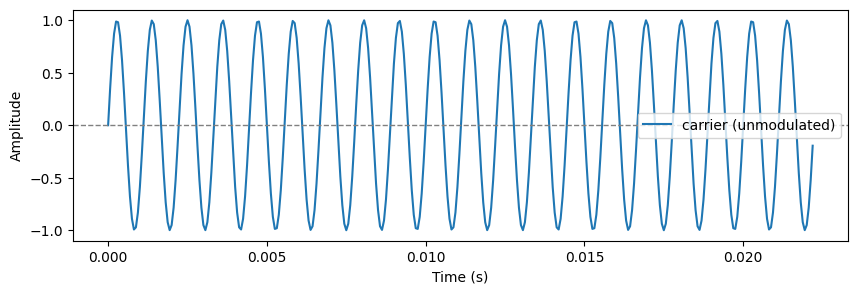

In [2]:
carrier_freq = 900
duration = 20/carrier_freq # value chosen for smooth plotting
sf = 16000
t_plots = np.arange(0, duration, 1/sf)

# example carrier; the untouched signal
carrier = np.sin(2*np.pi*carrier_freq*t_plots)
plt.figure(figsize=(10, 3))
plt.plot(t_plots, carrier, color='tab:blue', label='carrier (unmodulated)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

#### Modulation depth and rate

C:\Users\carol\OneDrive\Documents\UMaastricht\AudioToolbox\NSLAudioToolbox\src\neural_audio\utils\mathfuncs.py:268: UserWarning: carrier_freq=900 Hz is not much greater than rate=128.0 Hz; envelope may not be well-defined (beating). Try 7200Hz
  warnings.warn(f"carrier_freq={carrier_freq} Hz is not much greater than rate={rate} Hz; envelope may not be well-defined (beating). Try {carrier_freq*8}Hz")


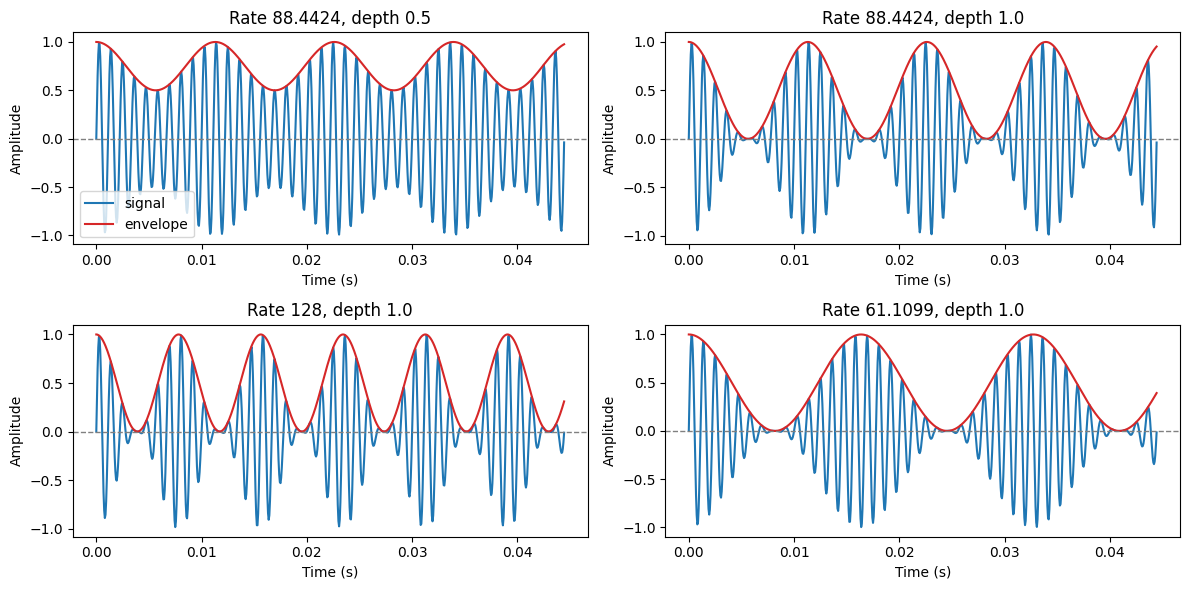

In [3]:
# Plots demonstrating how the signal is changed by the envelope defined by the rate and modulation depth
# (rate, depth, title) for each panel

carrier_freq = 900
duration = 40/carrier_freq # value chosen for smooth plotting
sf = 16000
t_plots = np.arange(0, duration, 1/sf)

panels = [
    (half_rates[14], 0.5),
    (half_rates[14], 1.0),
    (half_rates[15], 1.0),
    (half_rates[13], 1.0),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for ax, (rate, depth) in zip(axes.flat, panels):
    title = f"Rate {rate:g}, depth {depth}"
    signal, envelope = mf.gen_temporal_modulations_rate(rate, carrier_freq=carrier_freq, depth=depth, duration=duration)
    ax.plot(t_plots, signal, color='tab:blue', label='signal')
    ax.plot(t_plots, envelope, color='tab:red', label='envelope')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

axes[0, 0].legend()
plt.tight_layout()
plt.show()

#### Window

It would perhaps be possible to avoid edge artefacts by simply requiring the envelope to start at zero rather than at 1, its maximum amplitude. However, this would only help in the case where `depth = 1` since any other choice would mean the signal still starts abruptly at some nonzero value. This is why a Hann window is optionally available instead, and the proportion of the signal used can be tuned using the `ramp_frac` parameter.

rate: 88.44242431793768


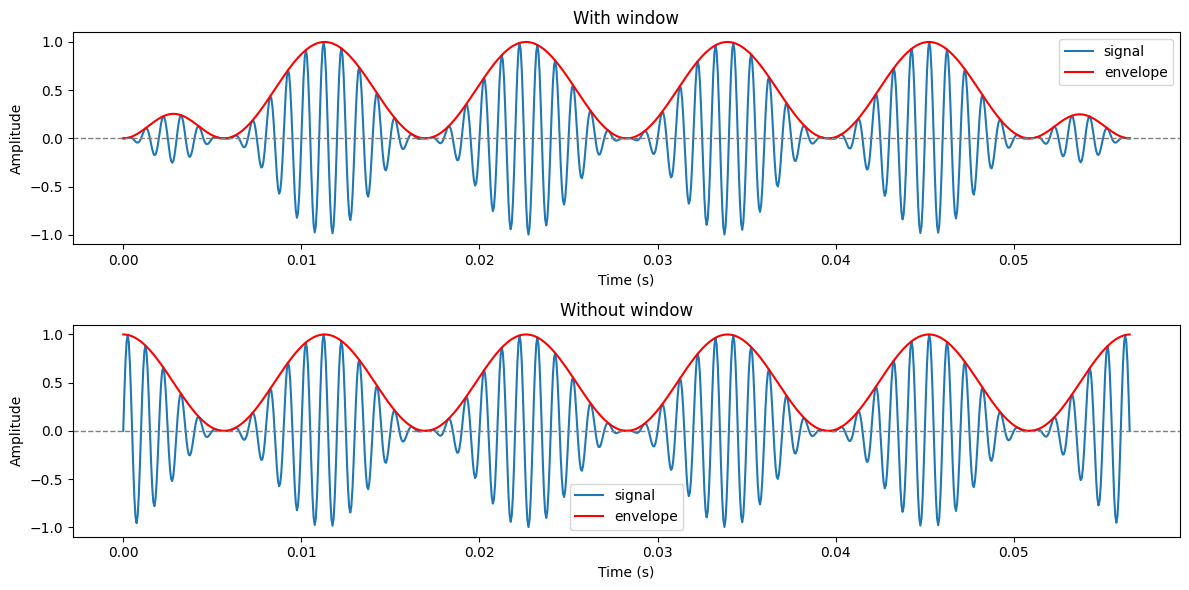

In [4]:
chosen_rate = half_rates[14] # works well for visualization with default carrier freq
d = 5 / chosen_rate # duration in seconds, chosen to get an integer number of cycles of the envelope
t = np.arange(0, d, 1/16000) # uses default sf

print(f"rate: {chosen_rate}")
windowed = mf.gen_temporal_modulations_rate(chosen_rate, ramp=True, ramp_frac=0.1, duration=d)
non_windowed = mf.gen_temporal_modulations_rate(chosen_rate, ramp=False, duration=d)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
titles = ["With window", "Without window", "Audiogram with window", "Audiogram without window"]

for i, data in zip(range(len(axes.flat)), [windowed, non_windowed]):
    signal, envelope = data
    
    axes[i].plot(t, signal, label="signal")
    
    axes[i].plot(t, envelope, color="red", label="envelope")
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()

plt.tight_layout()
plt.show()


#### **Examples**
The code below shows how a signal temporally modulated in this fashion is processed by the auditory model. It is expected that the cochlear representation will show the energy peaking at the specified rate, whereas there should be little spectral change, since the carrier oscillates at a constant frequency. Default parameters are used unless otherwise specified. To hear the sound, click the play button on the widget below the audiogram. It should sound something like a ringing noise.

> The time-resolved view (`plot_cr_temporal`) is used here rather than `plot_cr_projection`, which averages over time — the very axis the ramp acts on. Note that the onset artefact is suppressed more than the offset one: the filters in `gen_cort` are causal, so energy is smeared forward in time and cannot be tapered away from the stimulus side.

---
#### With ramp

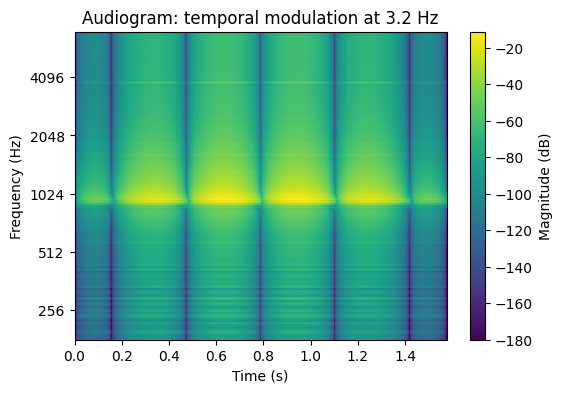

In [4]:
chosen_rate = half_rates[5]
duration = 5/chosen_rate # to get nice symmetry :)
waveform, envelope =  mf.gen_temporal_modulations_rate(chosen_rate, ramp=True, ramp_frac=0.45, duration=duration)


time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies, title=f"Audiogram: temporal modulation at {chosen_rate:.1f} Hz")
plt.show()
display(Audio(waveform, rate=16000))

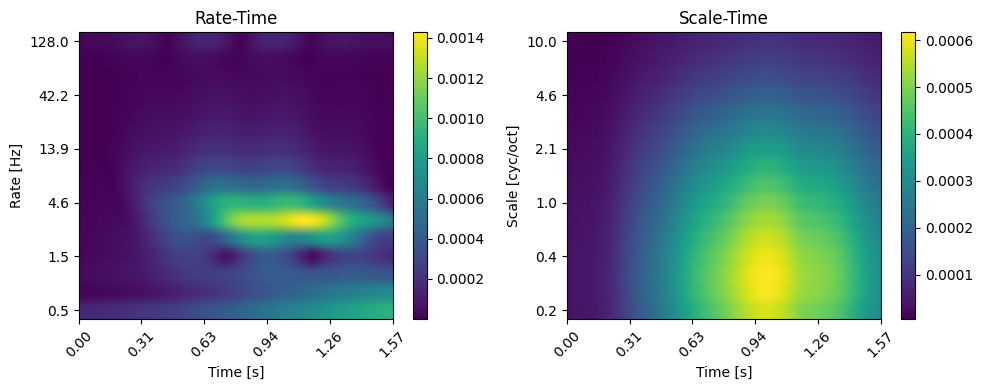

In [5]:
# Cortical representation (time-resolved) for ramp version
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_temporal(cr, half_rates, scales=half_scales, time_points=time_points)
plt.show()

---
#### Without ramp

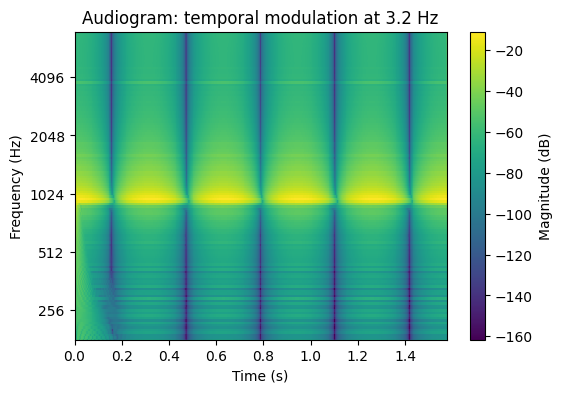

In [6]:
chosen_rate = half_rates[5]
duration = 5/chosen_rate
waveform, envelope =  mf.gen_temporal_modulations_rate(chosen_rate, ramp=False, duration=duration)


time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies, title=f"Audiogram: temporal modulation at {chosen_rate:.1f} Hz")
plt.show()
display(Audio(waveform, rate=16000))

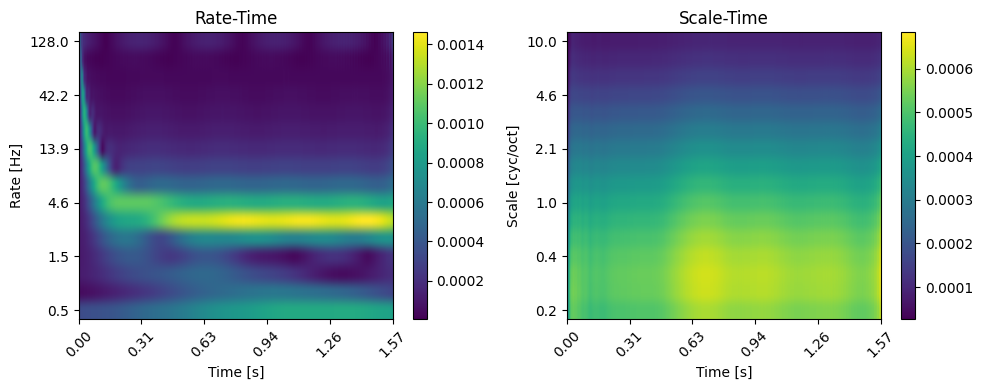

In [7]:
# Cortical representation (time-resolved) WITHOUT ramp
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_temporal(cr, half_rates, scales=half_scales, time_points=time_points)
plt.show()

---
## `gen_temporal_bursts_rate`

`gen_temporal_bursts_rate` places evenly spaced broadband bursts along the time axis, at `rate` bursts per second. Each burst momentarily contains every frequency, so all frequency channels switch on and off together, which sounds like a clicking noise. To hear the generated sound, click the play button on the widget. The plot below illustrates what the waveform looks like (sampling rate of 16kHz assumed)

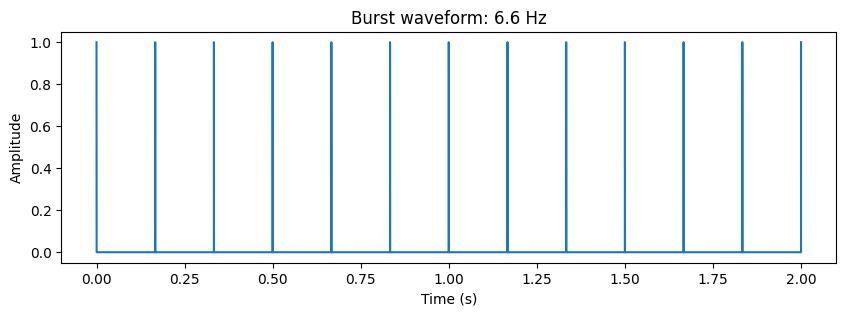

In [4]:
rate = half_rates[7] # change this parameter to explore the effects of using different rates
waveform = mf.gen_temporal_bursts_rate(rate)

t = np.arange(len(waveform)) / 16000   # time axis in seconds

plt.figure(figsize=(10, 3))
plt.plot(t, waveform, color='tab:blue')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Burst waveform: {rate:.1f} Hz')
plt.show()

display(Audio(waveform, rate=16000))

### **Important note on artefacts**
As seen in the audiogram below, due to how `wav2aud` is designed to mimic the mammalian auditory system, these infinitesimally small bursts are prone to ringing artefacts from the cochlear filters, which produce a triangular shape in the audiogram rather than the pure vertical stripes one might expect. A classic spectrogram of the same signal is provided for comparison on the left, which shows the pure vertical stripes.

As a result, the cortical representation may not show the energy peaking at the expected (given) rate. 

At higher rates, the decay effect due to ringing adds together as the decays overlap with the next burst, forming a low-energy but near-continuous signal at low frequencies. This can result in a smearing effect in the panels of the cortical representation that display frequency.

At lower rates, the duration of the decay is significantly longer than the duration of the burst itself, so the effect of the decay may hold a higher 'weight' than the bursts. Then although the signal originally had no spectral modulation, it becomes present due to the ringing introduced by aud2cor's filters and may show up strongly on the cortical representation visualizations.

**We have chosen to leave this function available as it may be useful to generate synthetic sounds for other contexts, but it is recommended to use `gen_temporal_modulations_rate` with the model implemented by `wav2aud` and `aud2cor`.**

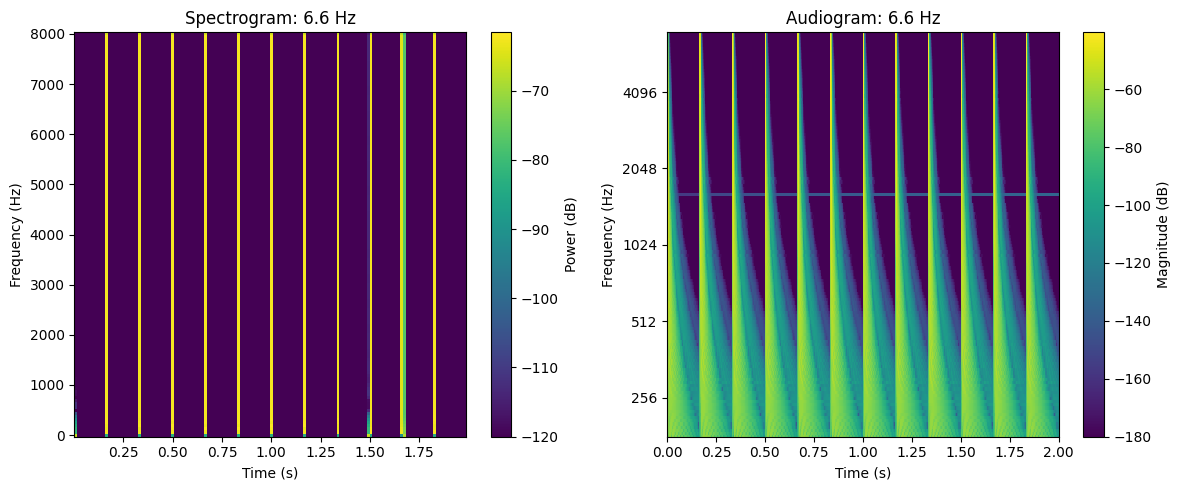

In [5]:

# classic spectrogram
f, t, Sxx = sig.spectrogram(waveform, fs=16000)

# audiogram
time_points, frequencies, audiogram = wav2aud(waveform)

plt.figure(figsize=(12, 5))

# left: classic spectrogram
plt.subplot(1, 2, 1)
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading='auto')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title(f'Spectrogram: {rate:.1f} Hz')
plt.colorbar(label='Power (dB)')

# right: audiogram
plt.subplot(1, 2, 2)
plot_spectrogram(audiogram, time_points, frequencies,
                 title=f'Audiogram: {rate:.1f} Hz')

plt.tight_layout()
plt.show()


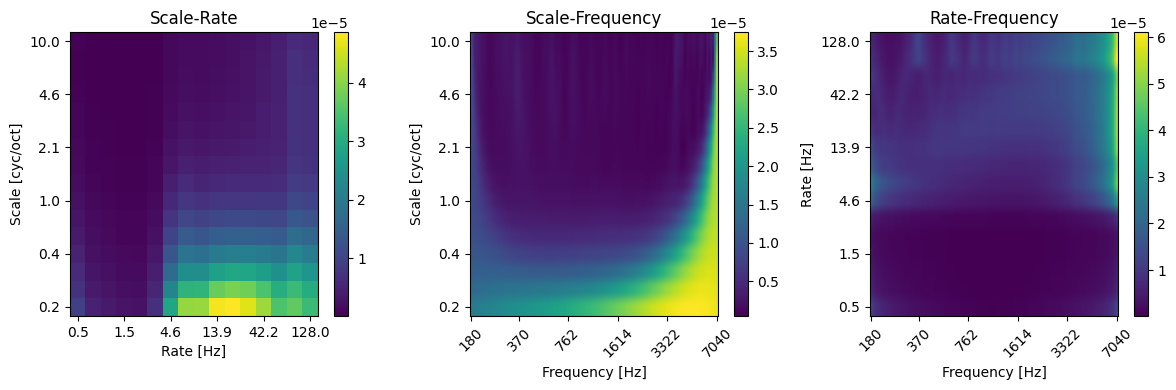

In [6]:
# Cortical representation (time-averaged projections)
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_projection(cr, half_rates, scales=half_scales, frequencies=frequencies)
plt.show()

(<Figure size 1000x400 with 4 Axes>,
 (<Axes: title={'center': 'Rate-Time'}, xlabel='Time [s]', ylabel='Rate [Hz]'>,
  <Axes: title={'center': 'Scale-Time'}, xlabel='Time [s]', ylabel='Scale [cyc/oct]'>))

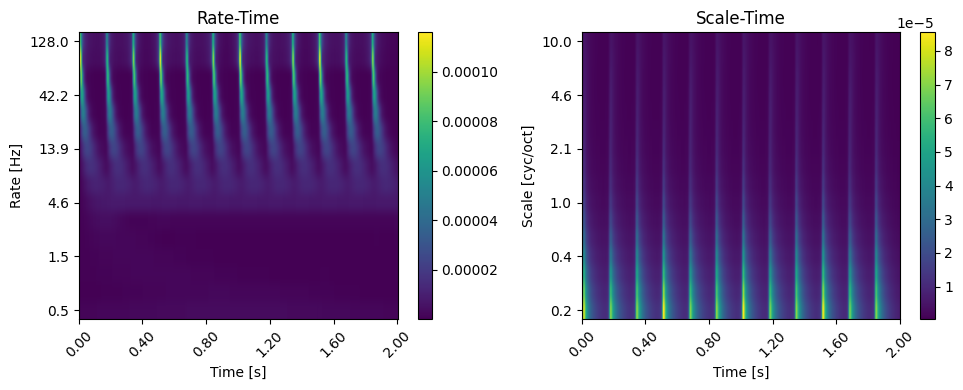

In [7]:
plot_cr_temporal(cr, half_rates, half_scales, time_points)

---
## **Spectral modulation**
## `gen_spectral_modulations_scale`

`gen_spectral_modulations_scale(scale)` sums a set of steady tones spaced evenly across log-frequency, with the requested `scale` (in cycles per octave) setting how densely they are packed. The tones do not change over time. In the audiogram this appears as horizontal stripes. In the cortical representation the energy concentrates at the matching scale and at the lowest rate, since nothing changes over time (look at the Scale-Rate panel).

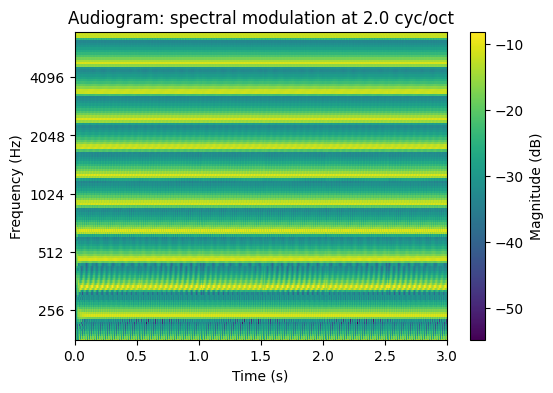

In [17]:
scale = 2#half_scales[10]
waveform = gen_spectral_modulations_scale(scale, duration=3)

# Audiogram
time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies,
                 title=f"Audiogram: spectral modulation at {scale:.1f} cyc/oct")
plt.show()

display(Audio(waveform, rate=16000))

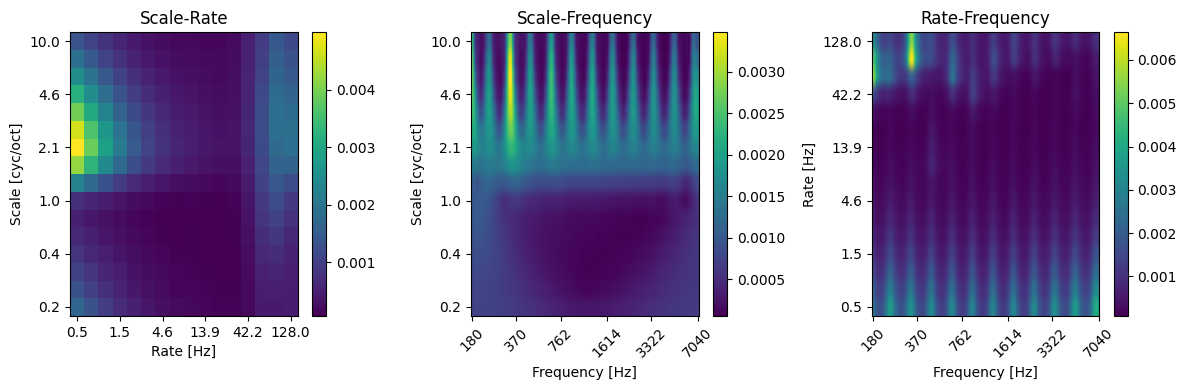

In [18]:
# Cortical representation (time-averaged projections)
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_projection(cr, half_rates, scales=half_scales, frequencies=frequencies)
plt.show()

(<Figure size 1000x400 with 4 Axes>,
 (<Axes: title={'center': 'Rate-Time'}, xlabel='Time [s]', ylabel='Rate [Hz]'>,
  <Axes: title={'center': 'Scale-Time'}, xlabel='Time [s]', ylabel='Scale [cyc/oct]'>))

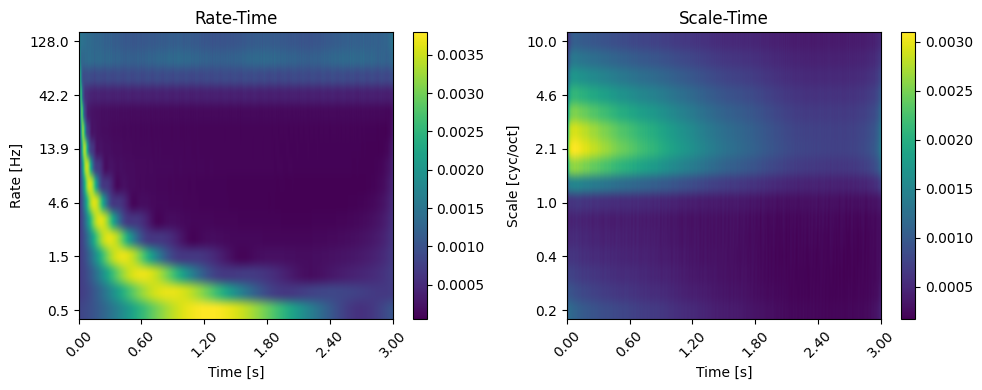

In [19]:
plot_cr_temporal(cr, half_rates, half_scales, time_points)

## Spectrotemporal ripples: `gen_ripple`

A ripple combines both kinds of modulation. `gen_ripple(rate, scale)` takes a set of steady tones and modulates their amplitudes with a single travelling wave that moves across both time and frequency, following Chi et al. (2005) [[1](#References)]. The `rate` sets how fast the pattern drifts in time and the `scale` sets how densely it repeats across frequency, producing a diagonal ripple in the audiogram.

In the cortical representation the energy concentrates at that single (rate, scale) pair that was used to generate the ripple, which is clearest as a bright spot in the Scale-Rate panel.

rate: 4.59479341998814Hz, scale: 0.9563524997900372 cycles/oct


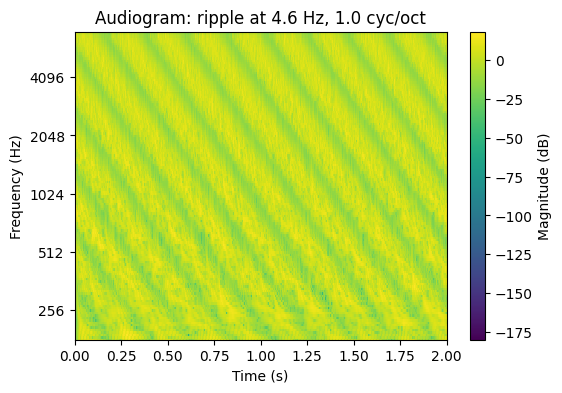

In [10]:
rate = half_rates[6]
scale = half_scales[6]
print(f"rate: {rate}Hz, scale: {scale} cycles/oct")
waveform = gen_ripple(rate=rate, scale=scale)

time_points, frequencies, audiogram = wav2aud(waveform)
plt.figure(figsize=(6, 4))
plot_spectrogram(audiogram, time_points, frequencies,
                 title=f"Audiogram: ripple at {rate:.1f} Hz, {scale:.1f} cyc/oct")
plt.show()


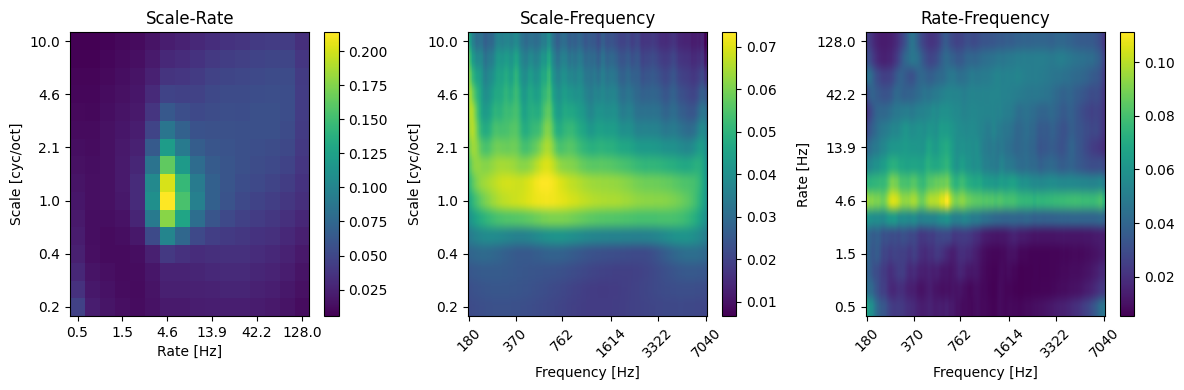

In [11]:
cr = aud2cor(audiogram, rates=half_rates, scales=half_scales)
plot_cr_projection(cr, half_rates, scales=half_scales, frequencies=frequencies)
plt.show()

## Directionality
To account for the fact that a sound may occur 'backwards' or 'forwards' in time, a rate may have a positive or negative direction. A practical example is a zipper sound; though the spectral content may be identical, our brains are able to perceive the difference between a 'zipping up' and a 'zipping down' sound.

**Ripples clearly show this directionality on an audiogram depending on whether the rate is positive or negative.** Typically, the direction associated with one sign is named 'upwards' and the other is named 'downwards', but the order is simply a convention. In this tutorial, positive is considered to be 'down' and negative is considered to be 'up'.


rates [Hz]: [ 0.5   0.91  1.64  2.97  5.38  9.75 17.67 32.  ]
probe ripple: 5.4 Hz, 1.6 cyc/oct


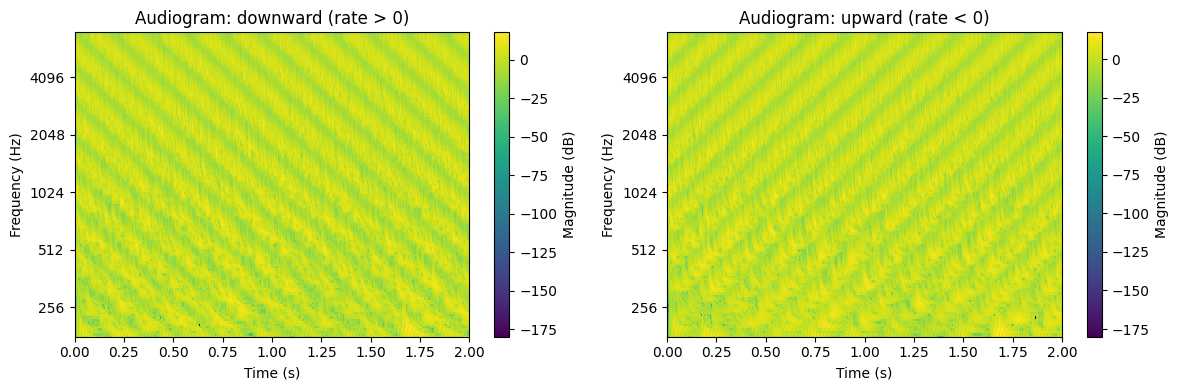

In [ ]:
# 8 x 8 scale-rate resolution used to reduce memory usage further
dir_rates = 2 ** np.linspace(np.log2(0.5), np.log2(32), 8)  
dir_scales = 2 ** np.linspace(np.log2(1/5), np.log2(8), 8)
probe_rate = dir_rates[4]
probe_scale = dir_scales[4]
print(f"rates [Hz]: {np.round(dir_rates, 2)}")
print(f"probe ripple: {probe_rate:.1f} Hz, {probe_scale:.1f} cyc/oct")

ripples = {
    "downward (rate > 0)": gen_ripple(rate=+probe_rate, scale=probe_scale, duration=2.0),
    "upward (rate < 0)":   gen_ripple(rate=-probe_rate, scale=probe_scale, duration=2.0),
}

# get audiogram for each stimulus
audiograms = {name: wav2aud(wave) for name, wave in ripples.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (tp, fr, aud)) in zip(axes, audiograms.items()):
    plt.sca(ax) # draw spectrogram on same plot
    plot_spectrogram(aud, tp, fr, title=f"Audiogram: {name}")
plt.tight_layout()
plt.show()

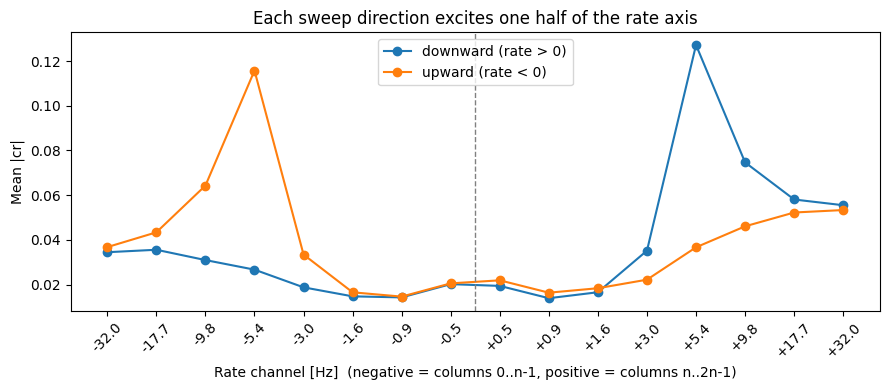

downward (rate > 0)    peak at  +5.38 Hz   peak/mirror = 4.77
upward (rate < 0)      peak at  -5.38 Hz   peak/mirror = 3.16


In [5]:
# Run each ripple through aud2cor and read off the rate axis.
# The two halves are laid out side by side on a single SIGNED rate axis:
# first half (sgn = -1) is drawn at negative rates, second half (sgn = +1) at positive.
n_rates = len(dir_rates)
signed_rates = np.concatenate([-dir_rates[::-1], dir_rates])
column_order = np.concatenate([np.arange(n_rates)[::-1], np.arange(n_rates) + n_rates])

profiles = {}
for name, (_, _, aud) in audiograms.items():
    cr = aud2cor(aud, rates=dir_rates, scales=dir_scales)
    # collapse everything except the rate axis, then reorder onto the signed axis
    profiles[name] = np.abs(cr).mean(axis=(0, 2, 3))[column_order]
    del cr  # ~130 MB per call, so don't hold both at once

fig, ax = plt.subplots(figsize=(9, 4))
for name, prof in profiles.items():
    ax.plot(range(2 * n_rates), prof, marker="o", label=name)

ax.axvline(n_rates - 0.5, color="grey", ls="--", lw=1)  # boundary between the two halves
ax.set_xticks(range(2 * n_rates))
ax.set_xticklabels([f"{s:+.1f}" for s in signed_rates], rotation=45)
ax.set_xlabel("Rate channel [Hz]  (negative = columns 0..n-1, positive = columns n..2n-1)")
ax.set_ylabel("Mean |cr|")
ax.set_title("Each sweep direction excites one half of the rate axis")
ax.legend(loc="upper center")
plt.tight_layout()
plt.show()

for name, prof in profiles.items():
    k = int(prof.argmax())
    print(f"{name:22s} peak at {signed_rates[k]:+6.2f} Hz   "
          f"peak/mirror = {prof[k] / prof[::-1][k]:.2f}")

### Plotting directionality

Directionality is not visible by default on any projection-based plots but can be visualized by passing in a flag or a particular slice of the corticogram. 

### Using `plot_cr_projection`

### Using `plot_cr_temporal`


# References
[1] Chi, Taishih & Ru, Powen & Shamma, Shihab (2005),
        "Multiresolution spectrotemporal analysis of complex sounds",
        The Journal of the Acoustical Society of America, 118, 887-906,
        10.1121/1.1945807